**1. Imports + dataset (same as video)**






In [ ]:
import numpy as np

# Same dataset used in the video
# x1 = house size (1..7)
# x2 = bedrooms
# y  = price
X = np.array([
    [1, 1],
    [2, 1],
    [3, 2],
    [4, 2],
    [5, 3],
    [6, 3],
    [7, 4]
], dtype=float)

y = np.array([1.0, 1.3, 1.6, 1.9, 2.1, 2.2, 2.5], dtype=float).reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7, 2)
y shape: (7, 1)


**2. Train/Val/Test split (tiny dataset → keep it simple)**

In [ ]:
# Because we only have 7 points, we’ll do:
# 5 train, 1 validation, 1 test
train_idx = np.array([0, 1, 2, 3, 4])
val_idx   = np.array([5])
test_idx  = np.array([6])

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (5, 2) (5, 1)
Val:   (1, 2) (1, 1)
Test:  (1, 2) (1, 1)


**3. Standardization (fit on TRAIN onl**y)

In [ ]:
# Standardize features using TRAIN stats only
mu = X_train.mean(axis=0)                 # mean per feature
sigma = X_train.std(axis=0, ddof=0)       # population std

# Avoid divide-by-zero (not needed here, but good practice)
sigma = np.where(sigma == 0, 1.0, sigma)

def standardize(X_in, mu, sigma):
    return (X_in - mu) / sigma

X_train_s = standardize(X_train, mu, sigma)
X_val_s   = standardize(X_val,   mu, sigma)
X_test_s  = standardize(X_test,  mu, sigma)

print("mu:", mu)
print("sigma:", sigma)
print("First standardized train row:", X_train_s[0])


mu: [3.  1.8]
sigma: [1.41421356 0.74833148]
First standardized train row: [-1.41421356 -1.06904497]


**4. Helper functions (predict, MSE)**

In [ ]:
def predict(X_in, w, b):
    # X_in: (n, d), w: (d, 1), b: scalar
    return X_in @ w + b

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


**5. Train with gradient descent (no regularization first)**

In [ ]:
def train_linear_regression_gd(
    X_train, y_train,
    X_val, y_val,
    lr=0.05,
    epochs=2000,
    l2_lambda=0.0,    # L2 regularization strength (0 = none)
    verbose_every=200
):
    n, d = X_train.shape

    # Initialize parameters
    w = np.zeros((d, 1))
    b = 0.0

    history = []

    for epoch in range(1, epochs + 1):
        # Forward pass
        y_hat = predict(X_train, w, b)
        error = (y_hat - y_train)  # (n, 1)

        # Gradients for MSE part
        grad_w = (2/n) * (X_train.T @ error)    # (d, 1)
        grad_b = (2/n) * np.sum(error)          # scalar

        # Add L2 gradient: d/dw (lambda * ||w||^2) = 2*lambda*w
        # (We regularize weights, not bias)
        grad_w = grad_w + 2 * l2_lambda * w

        # Update
        w = w - lr * grad_w
        b = b - lr * grad_b

        # Track losses
        train_loss = mse(y_train, predict(X_train, w, b))
        val_loss   = mse(y_val,   predict(X_val,   w, b))
        history.append((epoch, train_loss, val_loss))

        if verbose_every and epoch % verbose_every == 0:
            print(f"epoch {epoch:4d} | train MSE={train_loss:.4f} | val MSE={val_loss:.4f}")

    return w, b, np.array(history)






**Run on training data**

In [ ]:
w0, b0, hist0 = train_linear_regression_gd(
    X_train_s, y_train,
    X_val_s, y_val,
    lr=0.05,
    epochs=2000,
    l2_lambda=0.0,
    verbose_every=400
)

print("Learned w (no reg):", w0.ravel())
print("Learned b (no reg):", b0)
print("Final train MSE:", hist0[-1,1])
print("Final val   MSE:", hist0[-1,2])

epoch  400 | train MSE=0.0006 | val MSE=0.0511
epoch  800 | train MSE=0.0005 | val MSE=0.0569
epoch 1200 | train MSE=0.0005 | val MSE=0.0575
epoch 1600 | train MSE=0.0005 | val MSE=0.0576
epoch 2000 | train MSE=0.0005 | val MSE=0.0576
Learned w (no reg): [ 0.44311633 -0.04988484]
Learned b (no reg): 1.5799999999999992
Final train MSE: 0.0005333333350291474
Final val   MSE: 0.05759902500041399


**6. Plot train vs val loss (so overfitting is visible)**

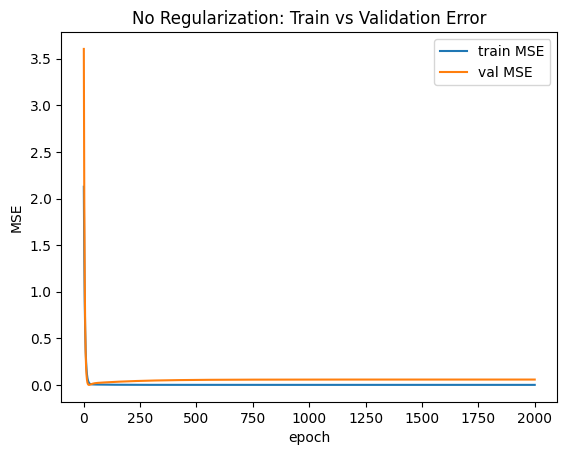

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(hist0[:,0], hist0[:,1], label="train MSE")
plt.plot(hist0[:,0], hist0[:,2], label="val MSE")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.title("No Regularization: Train vs Validation Error")
plt.show()


**7.Try L2 regularization (Ridge) and compare**

In [ ]:
w_l2, b_l2, hist_l2 = train_linear_regression_gd(
    X_train_s, y_train,
    X_val_s, y_val,
    lr=0.05,
    epochs=2000,
    l2_lambda=0.05,   # try 0.01, 0.05, 0.1
    verbose_every=400
)

print("Learned w (L2):", w_l2.ravel())
print("Learned b (L2):", b_l2)
print("Final train MSE:", hist_l2[-1,1])
print("Final val   MSE:", hist_l2[-1,2])


epoch  400 | train MSE=0.0022 | val MSE=0.0256
epoch  800 | train MSE=0.0021 | val MSE=0.0259
epoch 1200 | train MSE=0.0021 | val MSE=0.0259
epoch 1600 | train MSE=0.0021 | val MSE=0.0259
epoch 2000 | train MSE=0.0021 | val MSE=0.0259
Learned w (L2): [0.32090843 0.06246719]
Learned b (L2): 1.5799999999999992
Final train MSE: 0.0021433454569823604
Final val   MSE: 0.025895224454477433


**Plot**

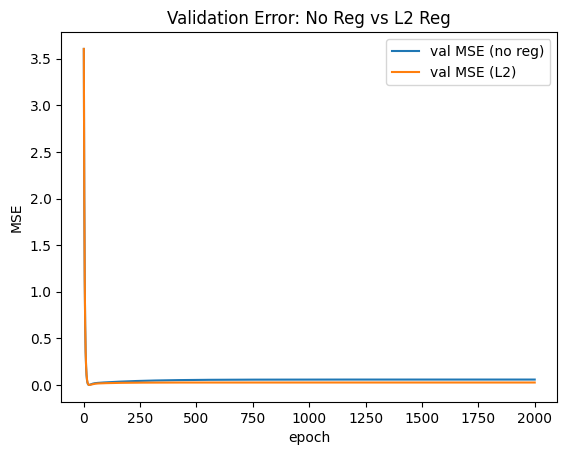

In [ ]:
plt.figure()
plt.plot(hist0[:,0], hist0[:,2], label="val MSE (no reg)")
plt.plot(hist_l2[:,0], hist_l2[:,2], label="val MSE (L2)")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.title("Validation Error: No Reg vs L2 Reg")
plt.show()


**8. Pick lambda using validation (simple grid search)**

In [ ]:
lambdas = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2]
results = []

for lam in lambdas:
    w_tmp, b_tmp, hist_tmp = train_linear_regression_gd(
        X_train_s, y_train,
        X_val_s, y_val,
        lr=0.05,
        epochs=2000,
        l2_lambda=lam,
        verbose_every=0
    )
    final_val = hist_tmp[-1,2]
    results.append((lam, final_val, w_tmp, b_tmp))

for lam, val_mse, _, _ in results:
    print(f"lambda={lam:>6} | final val MSE={val_mse:.4f}")

best = min(results, key=lambda t: t[1])
best_lambda, best_val_mse, best_w, best_b = best

print("\nBEST lambda:", best_lambda)
print("BEST val MSE:", best_val_mse)


lambda=   0.0 | final val MSE=0.0576
lambda= 0.001 | final val MSE=0.0563
lambda=  0.01 | final val MSE=0.0469
lambda=  0.05 | final val MSE=0.0259
lambda=   0.1 | final val MSE=0.0149
lambda=   0.2 | final val MSE=0.0051

BEST lambda: 0.2
BEST val MSE: 0.005132992930621754


**9. Final test evaluation (honest “final exam”)**

In [ ]:
y_test_pred = predict(X_test_s, best_w, best_b)
test_mse = mse(y_test, y_test_pred)

print("Test y:", y_test.ravel())
print("Test prediction:", y_test_pred.ravel())
print("Final TEST MSE:", test_mse)


Test y: [2.5]
Test prediction: [2.60245431]
Final TEST MSE: 0.010496885247019073
